# STEP 3 (Logistic Regression) - Model Training
In this step, we're going to train Logistic Regression models for each personality trait and embedding.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns   
import pickle
import numpy as np                                                                                                       
from sklearn.model_selection import train_test_split                                                                                                         
from sklearn.metrics import f1_score    
from pipeline.smote_oversampling import SMOTEOversampler    
from pipeline.machine_learning_algorithms.logistic_regression import LogisticRegressionClassifier


#### First, let's load the dataset and apply oversampling

TFIDF oversampling

In [2]:
def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df

In [3]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))                                                                                  
                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)                                               
                                                                                                                        
# Separando as 4 colunas                                                                                                
y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)           

Original dataset shape: X=(9322, 10000), y=(9322,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [4]:
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))                                                            

#### Now, We'll be training a model for TFIDF encodings

In [5]:
mbti_clf_tfidf = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [6]:
mbti_clf_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for N_S...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

All 4 models trained successfully! ✅


In [7]:
mbti_clf_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7821

              precision    recall  f1-score   support

           0       0.54      0.38      0.45       401
           1       0.83      0.90      0.86      1334

    accuracy                           0.78      1735
   macro avg       0.69      0.64      0.66      1735
weighted avg       0.76      0.78      0.77      1735


Evaluation for dimension: N_S
Accuracy: 0.8709

              precision    recall  f1-score   support

           0       0.55      0.35      0.43       240
           1       0.90      0.95      0.93      1495

    accuracy                           0.87      1735
   macro avg       0.73      0.65      0.68      1735
weighted avg       0.85      0.87      0.86      1735


Evaluation for dimension: T_F
Accuracy: 0.7914

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       939
           1       0.75      0.81      0.78       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [8]:
for key, value in mbti_clf_tfidf.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_tfidf_linear.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}") 

Salvo: models/logistic_regression/I_E_tfidf_linear.pkl
Salvo: models/logistic_regression/N_S_tfidf_linear.pkl
Salvo: models/logistic_regression/T_F_tfidf_linear.pkl
Salvo: models/logistic_regression/J_P_tfidf_linear.pkl


#### Next, W2V encodings

W2V oversampling

In [9]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))                                                                                  
                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)                                               
                                                                                                                  
y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)           

Original dataset shape: X=(9322, 500), y=(9322,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 500), y=(23456,)


In [10]:
mbti_clf_w2v = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [11]:
mbti_clf_w2v.fit(X_train_balanced, y_train_4cols)

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

 -> Training model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

All 4 models trained successfully! ✅


In [12]:
mbti_clf_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7193

              precision    recall  f1-score   support

           0       0.41      0.49      0.45       401
           1       0.84      0.79      0.81      1334

    accuracy                           0.72      1735
   macro avg       0.62      0.64      0.63      1735
weighted avg       0.74      0.72      0.73      1735


Evaluation for dimension: N_S
Accuracy: 0.7735

              precision    recall  f1-score   support

           0       0.31      0.53      0.39       240
           1       0.91      0.81      0.86      1495

    accuracy                           0.77      1735
   macro avg       0.61      0.67      0.63      1735
weighted avg       0.83      0.77      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.7660

              precision    recall  f1-score   support

           0       0.80      0.75      0.78       939
           1       0.73      0.78      0.75       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [13]:
for key, value in mbti_clf_w2v.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_w2v_linear.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")

Salvo: models/logistic_regression/I_E_w2v_linear.pkl
Salvo: models/logistic_regression/N_S_w2v_linear.pkl
Salvo: models/logistic_regression/T_F_w2v_linear.pkl
Salvo: models/logistic_regression/J_P_w2v_linear.pkl


#### Let's train a model for the posts before the augmentation, just as a matter of comparison

In [40]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))     

X_train_original = X_train[:6940]
y_train_original = y_train[:6940]                                        
                                                                                                           
y_train_4cols = divide_mbti(y_train_original)                                                                           
y_test_4cols = divide_mbti(y_test)           

In [41]:
mbti_clf_posts_tfidf = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [42]:
mbti_clf_posts_tfidf.fit(X_train_original, y_train_4cols)

Starting training process...
 -> Training model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for N_S...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

All 4 models trained successfully! ✅


In [43]:
mbti_clf_posts_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7896

              precision    recall  f1-score   support

           0       0.80      0.12      0.21       401
           1       0.79      0.99      0.88      1334

    accuracy                           0.79      1735
   macro avg       0.79      0.56      0.54      1735
weighted avg       0.79      0.79      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg       0.74      0.86      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.8219

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       939
           1       0.82      0.79      0.80       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [44]:
for key, value in mbti_clf_posts_tfidf.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_posts_tfidf_linear.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")

Salvo: models/logistic_regression/I_E_posts_tfidf_linear.pkl
Salvo: models/logistic_regression/N_S_posts_tfidf_linear.pkl
Salvo: models/logistic_regression/T_F_posts_tfidf_linear.pkl
Salvo: models/logistic_regression/J_P_posts_tfidf_linear.pkl


In [45]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))                                                                                  

X_train = X_train[:6940]
y_train = y_train[:6940]                                                

y_train_4cols = divide_mbti(y_train)                                                                           
y_test_4cols = divide_mbti(y_test)           

In [46]:
mbti_clf_posts_w2v = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [47]:
mbti_clf_posts_w2v.fit(X_train, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

 -> Training model for J_P...
All 4 models trained successfully! ✅


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

In [48]:
mbti_clf_posts_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7746

              precision    recall  f1-score   support

           0       0.54      0.18      0.27       401
           1       0.79      0.95      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.67      0.57      0.57      1735
weighted avg       0.74      0.77      0.73      1735


Evaluation for dimension: N_S
Accuracy: 0.8674

              precision    recall  f1-score   support

           0       0.66      0.09      0.15       240
           1       0.87      0.99      0.93      1495

    accuracy                           0.87      1735
   macro avg       0.76      0.54      0.54      1735
weighted avg       0.84      0.87      0.82      1735


Evaluation for dimension: T_F
Accuracy: 0.7879

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       939
           1       0.77      0.76      0.77       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [49]:
for key, value in mbti_clf_posts_w2v.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_posts_w2v_linear.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}") 

Salvo: models/logistic_regression/I_E_posts_w2v_linear.pkl
Salvo: models/logistic_regression/N_S_posts_w2v_linear.pkl
Salvo: models/logistic_regression/T_F_posts_w2v_linear.pkl
Salvo: models/logistic_regression/J_P_posts_w2v_linear.pkl


### Adding also a test without the SLM augmentation and only SMOTE.

In [24]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))     

X_train_original = X_train[:6940]
y_train_original = y_train[:6940]                                        
                                                                                                                                                                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_original, y_train_original)         

y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)           

Original dataset shape: X=(6940, 10000), y=(6940,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [25]:
mbti_clf_posts_oversampled_tfidf = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [31]:
mbti_clf_posts_oversampled_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for N_S...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

 -> Training model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

All 4 models trained successfully! ✅


In [32]:
mbti_clf_posts_oversampled_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7810

              precision    recall  f1-score   support

           0       0.53      0.48      0.50       401
           1       0.85      0.87      0.86      1334

    accuracy                           0.78      1735
   macro avg       0.69      0.68      0.68      1735
weighted avg       0.77      0.78      0.78      1735


Evaluation for dimension: N_S
Accuracy: 0.8622

              precision    recall  f1-score   support

           0       0.50      0.44      0.47       240
           1       0.91      0.93      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.71      0.69      0.70      1735
weighted avg       0.86      0.86      0.86      1735


Evaluation for dimension: T_F
Accuracy: 0.7908

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       939
           1       0.75      0.81      0.78       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [33]:
for key, value in mbti_clf_posts_oversampled_tfidf.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_posts_tfidf_linear_oversampled.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")

Salvo: models/logistic_regression/I_E_posts_tfidf_linear_oversampled.pkl
Salvo: models/logistic_regression/N_S_posts_tfidf_linear_oversampled.pkl
Salvo: models/logistic_regression/T_F_posts_tfidf_linear_oversampled.pkl
Salvo: models/logistic_regression/J_P_posts_tfidf_linear_oversampled.pkl


In [34]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))                                                                                  

X_train = X_train[:6940]
y_train = y_train[:6940]
                                                                                                        
X_train_original = X_train[:6940]
y_train_original = y_train[:6940]                                        
                                                                                                                                                                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_original, y_train_original)         

y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)       

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [35]:
mbti_clf_posts_oversampled_w2v = LogisticRegressionClassifier(                                                                                              
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
) 

In [36]:
mbti_clf_posts_oversampled_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

 -> Training model for N_S...
 -> Training model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

 -> Training model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

All 4 models trained successfully! ✅


In [37]:
mbti_clf_posts_oversampled_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.6830

              precision    recall  f1-score   support

           0       0.38      0.56      0.45       401
           1       0.85      0.72      0.78      1334

    accuracy                           0.68      1735
   macro avg       0.61      0.64      0.61      1735
weighted avg       0.74      0.68      0.70      1735


Evaluation for dimension: N_S
Accuracy: 0.7233

              precision    recall  f1-score   support

           0       0.27      0.60      0.38       240
           1       0.92      0.74      0.82      1495

    accuracy                           0.72      1735
   macro avg       0.60      0.67      0.60      1735
weighted avg       0.83      0.72      0.76      1735


Evaluation for dimension: T_F
Accuracy: 0.7631

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       939
           1       0.73      0.77      0.75       796

    accuracy                       

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

In [38]:
for key, value in mbti_clf_posts_oversampled_w2v.models.items():                                                                               
    caminho = f"models/logistic_regression/{key}_posts_w2v_linear_oversampled.pkl"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}") 

Salvo: models/logistic_regression/I_E_posts_w2v_linear_oversampled.pkl
Salvo: models/logistic_regression/N_S_posts_w2v_linear_oversampled.pkl
Salvo: models/logistic_regression/T_F_posts_w2v_linear_oversampled.pkl
Salvo: models/logistic_regression/J_P_posts_w2v_linear_oversampled.pkl


#### Finally, the results of them 

/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

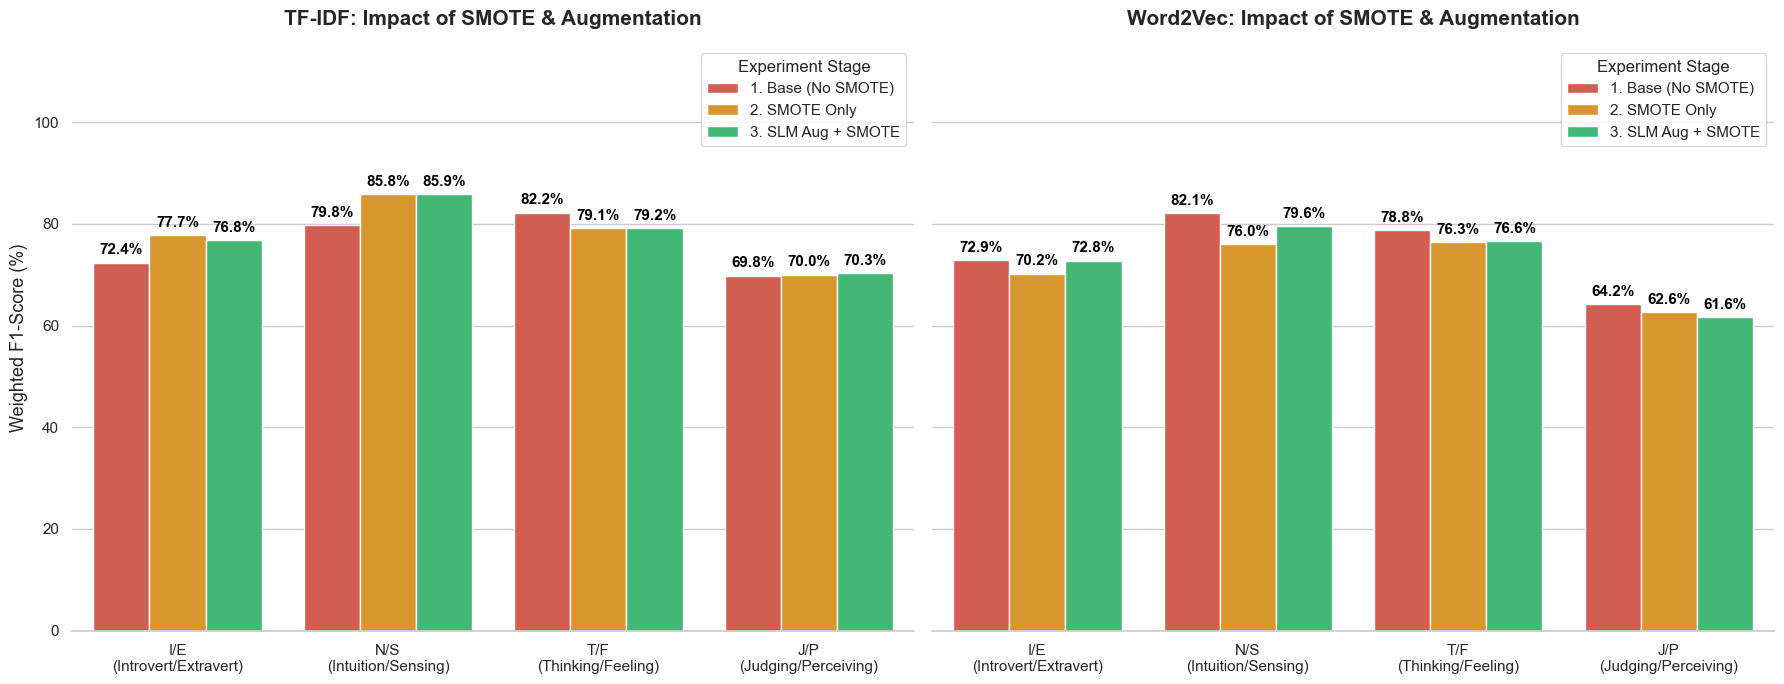

In [ ]:
import pickle                                                                                                                                
import pandas as pd                                                                                                                          
import matplotlib.pyplot as plt                                                                                                              
import seaborn as sns                                                                                                                        
from sklearn.metrics import f1_score                                                                                                         
                                                                                              
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                                                 
    X_test_tfidf = pickle.load(f)                                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                                                   
    X_test_w2v = pickle.load(f)                                                                                                              
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                                       
    y_test_raw = pd.Series(pickle.load(f))                                                                                                   
                                                                                                                                                
y_test_4cols = divide_mbti(y_test_raw)                                                                                    
pred_tfidf_base = mbti_clf_posts_tfidf.predict(X_test_tfidf)                                                                                 
pred_w2v_base = mbti_clf_posts_w2v.predict(X_test_w2v)                                                                                       
                                                                                                                                             
pred_tfidf_smote = mbti_clf_posts_oversampled_tfidf.predict(X_test_tfidf)                                                                    
pred_w2v_smote = mbti_clf_posts_oversampled_w2v.predict(X_test_w2v)                                                                          
                                                                                                                                            
pred_tfidf_aug = mbti_clf_tfidf.predict(X_test_tfidf)                                                                                        
pred_w2v_aug = mbti_clf_w2v.predict(X_test_w2v)                                                                                              
                                                                                                                                         
colunas = ['I_E', 'N_S', 'T_F', 'J_P']                                                                                                       
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']             
                                                                                                                                                
dados = []                                                                                                                                   
for i, col in enumerate(colunas):                                                                                                            
    # -------- TF-IDF --------                                                                                                               
    f1_t_base = f1_score(y_test_4cols[col], pred_tfidf_base[col], average='weighted') * 100                                                  
    f1_t_smote = f1_score(y_test_4cols[col], pred_tfidf_smote[col], average='weighted') * 100                                                
    f1_t_aug = f1_score(y_test_4cols[col], pred_tfidf_aug[col], average='weighted') * 100                                                    
                                                                                                                                                
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_base, 'Method': '1. Base (No SMOTE)', 'Embedding': 'TF-IDF'})                       
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_smote, 'Method': '2. SMOTE Only', 'Embedding': 'TF-IDF'})                           
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_aug, 'Method': '3. SLM Aug + SMOTE', 'Embedding': 'TF-IDF'})                        
                                                                                                                                                
    # -------- Word2Vec --------                                                                                                             
    f1_w_base = f1_score(y_test_4cols[col], pred_w2v_base[col], average='weighted') * 100                                                    
    f1_w_smote = f1_score(y_test_4cols[col], pred_w2v_smote[col], average='weighted') * 100
    f1_w_aug = f1_score(y_test_4cols[col], pred_w2v_aug[col], average='weighted') * 100
    
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_base, 'Method': '1. Base (No SMOTE)', 'Embedding': 'Word2Vec'})
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_smote, 'Method': '2. SMOTE Only', 'Embedding': 'Word2Vec'})
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_aug, 'Method': '3. SLM Aug + SMOTE', 'Embedding': 'Word2Vec'})

df_plot = pd.DataFrame(dados)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_theme(style="whitegrid")

paleta = ['#e74c3c', '#f39c12', '#2ecc71']

sns.barplot(data=df_plot[df_plot['Embedding'] == 'TF-IDF'], x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=axes[0])
axes[0].set_title("TF-IDF: Impact of SMOTE & Augmentation", fontsize=15, fontweight='bold', pad=15)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[0].set_xlabel("")

sns.barplot(data=df_plot[df_plot['Embedding'] == 'Word2Vec'], x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=axes[1])
axes[1].set_title("Word2Vec: Impact of SMOTE & Augmentation", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for ax in axes:
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', fontsize=11, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Experiment Stage', fontsize='11', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()